<a href="https://colab.research.google.com/github/amit-sw/colab_notebooks/blob/main/20260804_Goal_Progress_Agent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Educational Annual Goal Progress Agent

This Colab notebook compares five annual goals with dated email and chat messages stored as plain text.

Records are separated by a line containing `------`. The code does not parse that format. Each reader returns the complete file text and the Phase 1 agents interpret the content, dates, IDs, and current-date cutoff.

The graph is intentionally simple and sequential:

`loadInputs → emailAnalysis → chatAnalysis → consolidateProgress → evaluateGoals → createTextReport`

Set `TESTMODE = True` to call and inspect each agent separately.

## 1. Colab setup

Run the installation cell, then read `OPENAI_API_KEY` directly from Colab Secrets.

In [1]:
%pip install -q -U openai langgraph pydantic

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 247.8/247.8 kB 15.3 MB/s eta 0:00:00


In [6]:
from google.colab import userdata

OPENAI_API_KEY = userdata.get("OPENAI_API_KEY")

CURRENT_DATE = "2026-09-30"
GOALS_SOURCE = "/content/annual_goals.md"
EMAIL_SOURCE = "/content/email_messages.md"
CHAT_SOURCE = "/content/chat_messages.md"

TEXT_MODEL = "gpt-5.6-luna"
IMAGE_MODEL = "gpt-image-2"
REASONING_EFFORT = "medium"

TESTMODE = True
RUN_FULL_GRAPH = True
GENERATE_INFOGRAPH = True

In [7]:
import base64
import json
from collections.abc import Callable
from datetime import date
from enum import Enum
from pathlib import Path

from IPython.display import Image, Markdown, display
from openai import OpenAI
from pydantic import BaseModel, Field
from langgraph.graph import END, START, StateGraph

## 2. Plain-text source readers

Each function only reads and returns the complete source text. It does not split records or interpret fields. Replace these functions to read from another source while keeping the graph unchanged.

In [8]:
def read_goals(source: str) -> str:
    return Path(source).read_text(encoding="utf-8")


def read_emails(source: str) -> str:
    return Path(source).read_text(encoding="utf-8")


def read_chats(source: str) -> str:
    return Path(source).read_text(encoding="utf-8")

## 3. Agent structured-output models

Every LLM agent returns one of these Pydantic models. This makes intermediate results easy to inspect and prevents later agents from depending on free-form prose.

In [9]:
class SourceType(str, Enum):
    EMAIL = "email"
    CHAT = "chat"


class EvidenceCategory(str, Enum):
    MILESTONE = "milestone"
    OUTCOME = "outcome"
    BLOCKER = "blocker"
    DECISION = "decision"
    GOAL_CHANGE = "goal_change"
    DEVIATION = "deviation"


class Confidence(str, Enum):
    HIGH = "high"
    MEDIUM = "medium"
    LOW = "low"


class GoalStatus(str, Enum):
    ACHIEVED = "achieved"
    ON_TRACK = "on_track"
    AT_RISK = "at_risk"
    OFF_TRACK = "off_track"
    INSUFFICIENT_EVIDENCE = "insufficient_evidence"


class ChangeStatus(str, Enum):
    CONFIRMED = "confirmed"
    INFERRED = "inferred"


class EvidenceItem(BaseModel):
    source_type: SourceType
    source_id: str
    date: date
    goal_ids: list[str]
    category: EvidenceCategory
    summary: str
    excerpt: str
    confidence: Confidence


class Phase1Result(BaseModel):
    channel: SourceType
    evidence: list[EvidenceItem]
    irrelevant_message_ids: list[str]


class GoalChange(BaseModel):
    goal_id: str
    change_status: ChangeStatus
    original_goal: str
    active_goal: str
    rationale: str
    evidence_refs: list[str]


class GoalProgress(BaseModel):
    goal_id: str
    original_goal: str
    active_goal: str
    progress: list[str]
    blockers: list[str]
    deviations: list[str]
    changes: list[GoalChange]
    remaining_gaps: list[str]
    evidence_refs: list[str]


class ConsolidatedProgress(BaseModel):
    goals: list[GoalProgress]
    cross_goal_observations: list[str]


class GoalAssessment(BaseModel):
    goal_id: str
    title: str
    status: GoalStatus
    status_rationale: str
    progress: list[str]
    blockers: list[str]
    deviations: list[str]
    goal_changes: list[GoalChange]
    remaining_gaps: list[str]
    next_actions: list[str]
    evidence_refs: list[str]


class PortfolioReport(BaseModel):
    as_of_date: date
    executive_summary: str
    assessments: list[GoalAssessment]
    cross_goal_observations: list[str]
    data_limitations: list[str]

## 4. Shared graph state and deterministic helpers

In [10]:
class AgentState(BaseModel):
    current_date: str = CURRENT_DATE
    goals_source: str = GOALS_SOURCE
    email_source: str = EMAIL_SOURCE
    chat_source: str = CHAT_SOURCE

    goals_text: str = ""
    emails_text: str = ""
    chats_text: str = ""
    email_result: Phase1Result | None = None
    chat_result: Phase1Result | None = None
    consolidated: ConsolidatedProgress | None = None
    final_report: PortfolioReport | None = None
    text_report: str = ""
    trace: list[str] = Field(default_factory=list)


def model_data(value):
    if isinstance(value, BaseModel):
        return value.model_dump(mode="json")
    if isinstance(value, list):
        return [model_data(item) for item in value]
    return value


def evidence_lookup(state):
    items = []
    if state.email_result:
        items.extend(state.email_result.evidence)
    if state.chat_result:
        items.extend(state.chat_result.evidence)
    return {item.source_id: item for item in items}


def format_refs(refs, lookup):
    labels = []
    for source_id in refs:
        item = lookup.get(source_id)
        if item:
            labels.append(f"[{item.source_type.value}:{source_id} | {item.date.isoformat()}]")
        else:
            labels.append(f"[{source_id}]")
    return " ".join(labels) if labels else "No supporting message evidence"


def bullet_lines(items, empty_text="None identified"):
    return [f"- {item}" for item in items] or [f"- {empty_text}"]

## 5. Build the sequential graph

The placeholder methods make it possible to define and test each agent in the same order as the reference notebook.

In [11]:
class GoalProgressAgent:
    def __init__(
        self,
        api_key=None,
        text_model=TEXT_MODEL,
        reasoning_effort=REASONING_EFFORT,
        goals_reader: Callable[[str], str] = read_goals,
        email_reader: Callable[[str], str] = read_emails,
        chat_reader: Callable[[str], str] = read_chats,
    ):
        self.client = OpenAI(api_key=api_key)
        self.text_model = text_model
        self.reasoning_effort = reasoning_effort
        self.goals_reader = goals_reader
        self.email_reader = email_reader
        self.chat_reader = chat_reader

        workflow = StateGraph(AgentState)
        workflow.add_node("loadInputs", self.loadInputs)
        workflow.add_node("emailAnalysis", self.emailAnalysis)
        workflow.add_node("chatAnalysis", self.chatAnalysis)
        workflow.add_node("consolidateProgress", self.consolidateProgress)
        workflow.add_node("evaluateGoals", self.evaluateGoals)
        workflow.add_node("createTextReport", self.createTextReport)

        workflow.add_edge(START, "loadInputs")
        workflow.add_edge("loadInputs", "emailAnalysis")
        workflow.add_edge("emailAnalysis", "chatAnalysis")
        workflow.add_edge("chatAnalysis", "consolidateProgress")
        workflow.add_edge("consolidateProgress", "evaluateGoals")
        workflow.add_edge("evaluateGoals", "createTextReport")
        workflow.add_edge("createTextReport", END)
        self.graph = workflow.compile()

    def _parse(self, instructions, payload, output_type):
        response = self.client.responses.parse(
            model=self.text_model,
            reasoning={"effort": self.reasoning_effort},
            instructions=instructions,
            input=json.dumps(payload, indent=2, default=str),
            text_format=output_type,
            store=False,
        )
        return response.output_parsed

    def loadInputs(self, state):
        raise NotImplementedError

    def emailAnalysis(self, state):
        raise NotImplementedError

    def chatAnalysis(self, state):
        raise NotImplementedError

    def consolidateProgress(self, state):
        raise NotImplementedError

    def evaluateGoals(self, state):
        raise NotImplementedError

    def createTextReport(self, state):
        raise NotImplementedError

## Agent 1 — Load and validate inputs

This is a deterministic agent: it validates the files, applies the current-date cutoff, and never calls an LLM.

In [12]:
def loadInputs(self, state: AgentState):
    goals_text = self.goals_reader(state.goals_source)
    emails_text = self.email_reader(state.email_source)
    chats_text = self.chat_reader(state.chat_source)

    print(f"Goals source: {len(goals_text):,} characters")
    print(f"Email source: {len(emails_text):,} characters")
    print(f"Chat source: {len(chats_text):,} characters")
    return {
        "goals_text": goals_text,
        "emails_text": emails_text,
        "chats_text": chats_text,
        "trace": ["loadInputs: read three raw text sources"],
    }


GoalProgressAgent.loadInputs = loadInputs

In [13]:
if TESTMODE:
    app = GoalProgressAgent(OPENAI_API_KEY)
    test_state = AgentState(current_date=CURRENT_DATE)
    result = app.graph.nodes["loadInputs"].invoke(test_state)
    print({name: len(result[name]) for name in ["goals_text", "emails_text", "chats_text"]})

Goals source: 2,361 characters
Email source: 15,504 characters
Chat source: 14,267 characters
{'goals_text': 2361, 'emails_text': 15504, 'chats_text': 14267}


## Agent 2 — Email evidence analysis

Phase 1 begins by selecting only email evidence that helps evaluate one or more goals.

In [14]:
def emailAnalysis(self, state: AgentState):
    instructions = """Read the annual goals and the complete plain-text email collection.
The collection uses a line containing ------ between messages, but infer the
records from the text rather than asking the application to parse them.

Consider only messages dated from January 1 of the goal year through
CURRENT_DATE. Ignore later messages. Return one EvidenceItem for each distinct
goal-relevant fact, using exact message IDs and dates from the source. Map only
to goal IDs present in the goal text. Keep excerpts under 160 characters.
Classify milestones, outcomes, blockers, decisions, goal changes, and deviations.
List irrelevant in-range message IDs in irrelevant_message_ids. Do not evaluate
the final status of any goal."""
    payload = {
        "current_date": state.current_date,
        "annual_goals_text": state.goals_text,
        "email_collection_text": state.emails_text,
    }
    result = self._parse(instructions, payload, Phase1Result)
    if result.channel != SourceType.EMAIL:
        raise ValueError("The email agent must return channel='email'.")
    return {
        "email_result": result,
        "trace": state.trace + [f"emailAnalysis: selected {len(result.evidence)} evidence items"],
    }


GoalProgressAgent.emailAnalysis = emailAnalysis

In [15]:
if TESTMODE:
    app = GoalProgressAgent(OPENAI_API_KEY)
    loaded = app.graph.nodes["loadInputs"].invoke(AgentState(current_date=CURRENT_DATE))
    test_state = AgentState(current_date=CURRENT_DATE, **loaded)
    result = app.graph.nodes["emailAnalysis"].invoke(test_state)
    display(result["email_result"].model_dump(mode="json"))

Goals source: 2,361 characters
Email source: 15,504 characters
Chat source: 14,267 characters


{'channel': 'email',
 'evidence': [{'source_type': 'email',
   'source_id': 'E001',
   'date': '2026-01-12',
   'goal_ids': ['G1'],
   'category': 'decision',
   'summary': 'Portal beta and general-availability dates were retained, with scope approval assigned for March.',
   'excerpt': 'We are keeping the June 30 beta and September 15 general-availability dates.',
   'confidence': 'high'},
  {'source_type': 'email',
   'source_id': 'E021',
   'date': '2026-01-28',
   'goal_ids': ['G1'],
   'category': 'outcome',
   'summary': 'Customer research identified self-service billing and access control as the highest-value portal features.',
   'excerpt': 'Customer interviews confirm self-service billing and access control as the two highest-value portal features.',
   'confidence': 'high'},
  {'source_type': 'email',
   'source_id': 'E029',
   'date': '2026-01-30',
   'goal_ids': ['G2'],
   'category': 'outcome',
   'summary': 'The 2025 reliability baseline was four Sev-1 incidents and 99.81

## Agent 3 — Chat evidence analysis

The second Phase 1 agent applies the same evidence contract to chat messages.

In [16]:
def chatAnalysis(self, state: AgentState):
    instructions = """Read the annual goals and the complete plain-text chat collection.
The collection uses a line containing ------ between messages, but infer the
records from the text rather than asking the application to parse them.

Consider only messages dated from January 1 of the goal year through
CURRENT_DATE. Ignore later messages. Return one EvidenceItem for each distinct
goal-relevant fact, using exact message IDs and dates from the source. Map only
to goal IDs present in the goal text. Keep excerpts under 160 characters.
Classify milestones, outcomes, blockers, decisions, goal changes, and deviations.
List irrelevant in-range message IDs in irrelevant_message_ids. Do not evaluate
the final status of any goal."""
    payload = {
        "current_date": state.current_date,
        "annual_goals_text": state.goals_text,
        "chat_collection_text": state.chats_text,
    }
    result = self._parse(instructions, payload, Phase1Result)
    if result.channel != SourceType.CHAT:
        raise ValueError("The chat agent must return channel='chat'.")
    return {
        "chat_result": result,
        "trace": state.trace + [f"chatAnalysis: selected {len(result.evidence)} evidence items"],
    }


GoalProgressAgent.chatAnalysis = chatAnalysis

In [17]:
if TESTMODE:
    app = GoalProgressAgent(OPENAI_API_KEY)
    loaded = app.graph.nodes["loadInputs"].invoke(AgentState(current_date=CURRENT_DATE))
    test_state = AgentState(current_date=CURRENT_DATE, **loaded)
    result = app.graph.nodes["chatAnalysis"].invoke(test_state)
    display(result["chat_result"].model_dump(mode="json"))

Goals source: 2,361 characters
Email source: 15,504 characters
Chat source: 14,267 characters


{'channel': 'chat',
 'evidence': [{'source_type': 'chat',
   'source_id': 'C001',
   'date': '2026-01-15',
   'goal_ids': ['G1'],
   'category': 'milestone',
   'summary': 'Portal technical design began, with the June beta date still considered realistic.',
   'excerpt': 'Portal technical design starts Monday; the June beta date still looks realistic.',
   'confidence': 'high'},
  {'source_type': 'chat',
   'source_id': 'C031',
   'date': '2026-02-06',
   'goal_ids': ['G1'],
   'category': 'milestone',
   'summary': 'Customer portal copy review was completed.',
   'excerpt': 'Customer portal copy review is complete.',
   'confidence': 'high'},
  {'source_type': 'chat',
   'source_id': 'C039',
   'date': '2026-02-06',
   'goal_ids': ['G2'],
   'category': 'milestone',
   'summary': 'Service-level objective dashboards became visible.',
   'excerpt': 'All service SLO dashboards are visible.',
   'confidence': 'high'},
  {'source_type': 'chat',
   'source_id': 'C047',
   'date': '2026-02-0

## Agent 4 — Consolidate progress and goal changes

Phase 2 combines both channels. It preserves conflicts and distinguishes the original goal from an explicitly or implicitly revised active goal.

In [18]:
def consolidateProgress(self, state: AgentState):
    instructions = '''Consolidate email and chat evidence for exactly five goals.
Return one GoalProgress per supplied goal, even when evidence is absent. Deduplicate
repeated facts but retain conflicting claims and cite all supporting source IDs.

A confirmed goal change has an explicit approval or decision. An inferred goal
change requires at least two agreeing, non-duplicate messages on different dates
and no later contradiction. A single or ambiguous signal is a deviation, not a
new baseline. Always preserve original_goal and state active_goal separately.
Do not assign final on-track statuses.'''
    payload = {
        "current_date": state.current_date,
        "annual_goals_text": state.goals_text,
        "email_evidence": model_data(state.email_result.evidence),
        "chat_evidence": model_data(state.chat_result.evidence),
    }
    result = self._parse(instructions, payload, ConsolidatedProgress)
    valid_refs = set(evidence_lookup(state))
    used_refs = {ref for goal in result.goals for ref in goal.evidence_refs}
    if not used_refs.issubset(valid_refs):
        raise ValueError(f"Unknown evidence references: {sorted(used_refs - valid_refs)}")
    return {
        "consolidated": result,
        "trace": state.trace + ["consolidateProgress: combined both evidence channels"],
    }


GoalProgressAgent.consolidateProgress = consolidateProgress

In [19]:
if TESTMODE:
    app = GoalProgressAgent(OPENAI_API_KEY)
    loaded = app.graph.nodes["loadInputs"].invoke(AgentState(current_date=CURRENT_DATE))
    sample_email = Phase1Result(
        channel=SourceType.EMAIL,
        evidence=[EvidenceItem(source_type=SourceType.EMAIL, source_id="E010", date=date(2026,7,8), goal_ids=["G3"], category=EvidenceCategory.GOAL_CHANGE, summary="CEO approved a smaller enterprise-focused target.", excerpt="Revise the year-end target", confidence=Confidence.HIGH)],
        irrelevant_message_ids=[],
    )
    sample_chat = Phase1Result(
        channel=SourceType.CHAT,
        evidence=[EvidenceItem(source_type=SourceType.CHAT, source_id="C013", date=date(2026,7,9), goal_ids=["G3"], category=EvidenceCategory.GOAL_CHANGE, summary="Sales repeated the approved revised target.", excerpt="New approved target is eight", confidence=Confidence.HIGH)],
        irrelevant_message_ids=[],
    )
    test_state = AgentState(current_date=CURRENT_DATE, **loaded, email_result=sample_email, chat_result=sample_chat)
    result = app.graph.nodes["consolidateProgress"].invoke(test_state)
    display(result["consolidated"].model_dump(mode="json"))

Goals source: 2,361 characters
Email source: 15,504 characters
Chat source: 14,267 characters


{'goals': [{'goal_id': 'G1',
   'original_goal': 'Launch the customer portal: deliver the new self-service customer portal from beta through general availability, with beta by 2026-06-30, general availability by 2026-09-15, and at least 100 active customer accounts by 2026-09-30.',
   'active_goal': 'Launch the customer portal: deliver the new self-service customer portal from beta through general availability, with beta by 2026-06-30, general availability by 2026-09-15, and at least 100 active customer accounts by 2026-09-30.',
   'progress': [],
   'blockers': [],
   'deviations': [],
   'changes': [],
   'remaining_gaps': ['No email or chat evidence was provided for this goal.'],
   'evidence_refs': []},
  {'goal_id': 'G2',
   'original_goal': 'Improve platform reliability: reach 99.9 percent rolling uptime by 2026-12-31, reduce Sev-1 incidents by 30 percent versus 2025, and complete failover and peak-load readiness exercises.',
   'active_goal': 'Improve platform reliability: reach

## Agent 5 — Evaluate each goal

This agent applies a shared qualitative rubric to the consolidated evidence as of the cutoff date.

In [20]:
def evaluateGoals(self, state: AgentState):
    instructions = '''Evaluate exactly five annual goals as of the supplied date.
Use the active goal when a confirmed or qualifying inferred change exists, while
making the difference from the original goal visible.

Status rubric:
- achieved: all active success criteria are met.
- on_track: due milestones are met and remaining work has credible forward evidence.
- at_risk: a material delay or blocker exists, but recovery remains plausible.
- off_track: an important due target is missed or evidence shows inadequate pace without a credible recovery.
- insufficient_evidence: evidence cannot support a responsible judgment.

Every material statement and next action must remain grounded in the consolidated
record. Copy source IDs into evidence_refs; do not invent IDs or facts.'''
    payload = {
        "current_date": state.current_date,
        "annual_goals_text": state.goals_text,
        "consolidated_progress": model_data(state.consolidated),
    }
    report = self._parse(instructions, payload, PortfolioReport)
    valid_refs = set(evidence_lookup(state))
    used_refs = {ref for item in report.assessments for ref in item.evidence_refs}
    if not used_refs.issubset(valid_refs):
        raise ValueError(f"Unknown report evidence references: {sorted(used_refs - valid_refs)}")
    return {
        "final_report": report,
        "trace": state.trace + ["evaluateGoals: created the five goal assessments"],
    }


GoalProgressAgent.evaluateGoals = evaluateGoals

In [21]:
if TESTMODE:
    app = GoalProgressAgent(OPENAI_API_KEY)
    loaded = app.graph.nodes["loadInputs"].invoke(AgentState(current_date=CURRENT_DATE))
    empty_progress = ConsolidatedProgress(
        goals=[GoalProgress(goal_id=goal_id, original_goal="See raw goals text", active_goal="See raw goals text", progress=[], blockers=[], deviations=[], changes=[], remaining_gaps=["No evidence supplied in this isolated test."], evidence_refs=[]) for goal_id in ["G1", "G2", "G3", "G4", "G5"]],
        cross_goal_observations=[],
    )
    test_state = AgentState(current_date=CURRENT_DATE, **loaded, consolidated=empty_progress)
    result = app.graph.nodes["evaluateGoals"].invoke(test_state)
    display(result["final_report"].model_dump(mode="json"))

Goals source: 2,361 characters
Email source: 15,504 characters
Chat source: 14,267 characters


{'as_of_date': '2026-09-30',
 'executive_summary': 'The consolidated record contains no progress evidence, blockers, deviations, goal changes, or source IDs for any of the five 2026 goals. Accordingly, none can be responsibly rated against its success criteria or due milestones; all five statuses are insufficient_evidence.',
 'assessments': [{'goal_id': 'G1',
   'title': 'Launch the customer portal',
   'status': 'insufficient_evidence',
   'status_rationale': 'No evidence is supplied to determine whether beta availability by 2026-06-30, general availability by 2026-09-15, or at least 100 active customer accounts by 2026-09-30 was achieved.',
   'progress': [],
   'blockers': [],
   'deviations': [],
   'goal_changes': [],
   'remaining_gaps': ['Evidence of beta release to design partners.',
    'Evidence of general availability release.',
    'Evidence of at least 100 active customer accounts.',
    'Evidence against the 2026-03-31, 2026-06-30, and 2026-09-15 milestones.'],
   'next_a

## Agent 6 — Create the text report

This final graph node is deterministic. It converts the structured evaluation into auditable Markdown and writes `annual_progress_report.md`.

In [22]:
def render_markdown(state: AgentState):
    report = state.final_report
    lookup = evidence_lookup(state)
    lines = [
        "# Annual Goal Progress Report",
        "",
        f"**As of:** {report.as_of_date.isoformat()}",
        "",
        "## Executive summary",
        "",
        report.executive_summary,
        "",
        "## Goal status",
        "",
        "| Goal | Status | Rationale |",
        "|---|---|---|",
    ]
    for item in report.assessments:
        lines.append(f"| {item.goal_id}: {item.title} | {item.status.value.replace('_', ' ').title()} | {item.status_rationale} |")

    for item in report.assessments:
        lines.extend(["", f"## {item.goal_id}: {item.title}", "", f"**Status:** {item.status.value.replace('_', ' ').title()}", "", item.status_rationale])
        if item.goal_changes:
            lines.extend(["", "### Goal changes", ""])
            for change in item.goal_changes:
                lines.append(f"- **{change.change_status.value.title()}** — {change.active_goal}. {change.rationale} {format_refs(change.evidence_refs, lookup)}")
                lines.append(f"  - Original: {change.original_goal}")
        for heading, values in [
            ("Progress", item.progress),
            ("Blockers", item.blockers),
            ("Deviations", item.deviations),
            ("Remaining gaps", item.remaining_gaps),
            ("Suggested next actions", item.next_actions),
        ]:
            lines.extend(["", f"### {heading}", "", *bullet_lines(values)])
        lines.extend(["", "### Evidence", "", format_refs(item.evidence_refs, lookup)])

    lines.extend(["", "## Cross-goal observations", "", *bullet_lines(report.cross_goal_observations)])
    lines.extend(["", "## Data limitations", "", *bullet_lines(report.data_limitations)])
    lines.extend(["", "## Evidence appendix", ""])
    for source_id, item in sorted(lookup.items(), key=lambda pair: (pair[1].date, pair[0])):
        lines.append(f"- {format_refs([source_id], lookup)} {item.summary} — “{item.excerpt}”")
    return "\n".join(lines)


def createTextReport(self, state: AgentState):
    text_report = render_markdown(state)
    Path("annual_progress_report.md").write_text(text_report, encoding="utf-8")
    print("Saved annual_progress_report.md")
    return {
        "text_report": text_report,
        "trace": state.trace + ["createTextReport: rendered and saved Markdown"],
    }


GoalProgressAgent.createTextReport = createTextReport

In [23]:
if TESTMODE:
    sample_report = PortfolioReport(
        as_of_date=date.fromisoformat(CURRENT_DATE),
        executive_summary="One-goal formatting example.",
        assessments=[GoalAssessment(goal_id="G1", title="Example goal", status=GoalStatus.ON_TRACK, status_rationale="The available milestone is complete.", progress=["Milestone completed."], blockers=[], deviations=[], goal_changes=[], remaining_gaps=["Finish the remaining work."], next_actions=["Confirm the next milestone."], evidence_refs=[])],
        cross_goal_observations=[],
        data_limitations=["This is an isolated formatting test."],
    )
    app = GoalProgressAgent(OPENAI_API_KEY)
    test_state = AgentState(final_report=sample_report)
    result = app.graph.nodes["createTextReport"].invoke(test_state)
    display(Markdown(result["text_report"]))

Saved annual_progress_report.md


# Annual Goal Progress Report

**As of:** 2026-09-30

## Executive summary

One-goal formatting example.

## Goal status

| Goal | Status | Rationale |
|---|---|---|
| G1: Example goal | On Track | The available milestone is complete. |

## G1: Example goal

**Status:** On Track

The available milestone is complete.

### Progress

- Milestone completed.

### Blockers

- None identified

### Deviations

- None identified

### Remaining gaps

- Finish the remaining work.

### Suggested next actions

- Confirm the next milestone.

### Evidence

No supporting message evidence

## Cross-goal observations

- None identified

## Data limitations

- This is an isolated formatting test.

## Evidence appendix


## 6. Inspect and run the complete graph

['__start__', 'loadInputs', 'emailAnalysis', 'chatAnalysis', 'consolidateProgress', 'evaluateGoals', 'createTextReport']


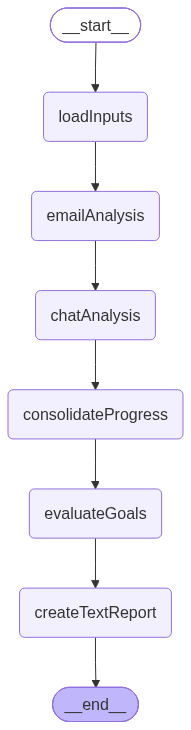

In [24]:
app = GoalProgressAgent(OPENAI_API_KEY)
print(list(app.graph.nodes))
display(Image(app.graph.get_graph().draw_mermaid_png()))

In [25]:
final_state = None

if RUN_FULL_GRAPH:
    initial_state = AgentState(
        current_date=CURRENT_DATE,
        goals_source=GOALS_SOURCE,
        email_source=EMAIL_SOURCE,
        chat_source=CHAT_SOURCE,
    )
    result = app.graph.invoke(initial_state)
    final_state = AgentState.model_validate(result)
    display(Markdown(final_state.text_report))

Goals source: 2,361 characters
Email source: 15,504 characters
Chat source: 14,267 characters
Saved annual_progress_report.md


# Annual Goal Progress Report

**As of:** 2026-09-30

## Executive summary

G1 is achieved: the portal met its active delivery, launch, and adoption criteria ahead of schedule. G2 is at risk because reliability performance remains below target and the peak-load exercise was deferred, although recovery is planned. G3 is at risk under the confirmed reduced targets because the fourth paid conversion remains unresolved in legal review. G4 is achieved against the inferred re-scoped focus on internal capability building, while the original hiring target remains unmet. G5 is off track: the September production milestone was missed, savings are well below target, and no credible recovery evidence is recorded.

## Goal status

| Goal | Status | Rationale |
|---|---|---|
| G1: Launch the customer portal | Achieved | All active success criteria are evidenced: beta launched by 2026-06-24, general availability launched on 2026-09-10, and active accounts reached at least 100. The launch occurred ahead of both stated dates, and no critical defects were reported. |
| G2: Improve platform reliability | At Risk | The goal has material schedule and performance gaps: the peak-load exercise was deferred beyond the 2026-09-30 milestone, rolling uptime was reported at 99.80 percent against the 99.9 percent target, and the Sev-1 reduction target was reported at risk. Recovery remains plausible because an October 22 load test and weekly reliability reviews were approved, but remediation work remains open. |
| G3: Grow the design-partner program | At Risk | The confirmed active goal reduces the year-end targets to 8 active partners and 4 paid contracts. Three paid contracts were complete, while the fourth remained in legal review and had missed the September milestone. A later claim described the fourth conversion as likely for the year, so recovery remains plausible but unconfirmed. |
| G4: Expand and develop the engineering team | Achieved | Against the inferred re-scoped active goal, both mentoring cohorts were completed, all engineers had documented development plans, and two cloud certifications were completed. The original three-hire target was not achieved because of the hiring and budget freezes, but the evidence supports the re-scoped capability-building focus. |
| G5: Automate recurring operating work | Off Track | The September milestone to place two automations into production was missed: only ticket-triage reached pilot, while KPI reporting and access review had not reached production. Weekly savings were approximately two hours versus the 10-hour target, and the record provides no credible recovery evidence while automation capacity remains constrained. |

## G1: Launch the customer portal

**Status:** Achieved

All active success criteria are evidenced: beta launched by 2026-06-24, general availability launched on 2026-09-10, and active accounts reached at least 100. The launch occurred ahead of both stated dates, and no critical defects were reported.

### Progress

- Scope and technical design were approved on 2026-03-27.
- Beta went live for all six design partners on 2026-06-24, ahead of the 2026-06-30 milestone.
- General availability launched on 2026-09-10, ahead of the 2026-09-15 target, with 112 active accounts and later 126 active accounts.
- Security review and customer documentation were complete, and post-launch reporting showed no critical defects.

### Blockers

- Three moderate accessibility issues and a low-severity export defect created launch risk, but the defect was fixed and the launch criteria were subsequently met.
- Portal response time was below the launch target on 2026-06-18.

### Deviations

- Accessibility and response-time issues introduced launch risk, but they did not prevent achievement of the stated active criteria.

### Remaining gaps

- There is no evidence confirming completion of longer-term operational or post-launch commitments beyond the stated general-availability and account criteria.

### Suggested next actions

- Monitor the longer-term operational and post-launch commitments that are not covered by the completed stated success criteria.

### Evidence

[email:E001 | 2026-01-12] [email:E004 | 2026-03-27] [email:E021 | 2026-01-28] [email:E022 | 2026-02-18] [email:E023 | 2026-04-15] [email:E024 | 2026-05-12] [email:E025 | 2026-06-10] [email:E008 | 2026-06-24] [chat:C001 | 2026-01-15] [chat:C006 | 2026-03-28] [chat:C010 | 2026-05-29] [chat:C012 | 2026-06-24] [chat:C031 | 2026-02-06] [chat:C032 | 2026-03-09] [chat:C033 | 2026-04-12] [chat:C034 | 2026-05-15] [chat:C035 | 2026-06-18] [email:E026 | 2026-07-22] [email:E027 | 2026-08-14] [chat:C036 | 2026-07-21] [chat:C037 | 2026-08-24] [chat:C021 | 2026-09-02] [email:E016 | 2026-09-10] [chat:C022 | 2026-09-10] [chat:C023 | 2026-09-12] [email:E028 | 2026-09-21] [chat:C038 | 2026-09-07]

## G2: Improve platform reliability

**Status:** At Risk

The goal has material schedule and performance gaps: the peak-load exercise was deferred beyond the 2026-09-30 milestone, rolling uptime was reported at 99.80 percent against the 99.9 percent target, and the Sev-1 reduction target was reported at risk. Recovery remains plausible because an October 22 load test and weekly reliability reviews were approved, but remediation work remains open.

### Progress

- SLOs and error-budget monitoring were published, with every production service assigned an owner, SLO, and dashboard.
- The regional failover exercise completed successfully on 2026-06-29 in 18 minutes.
- The escalation-list issue identified during an incident-command drill was corrected.
- Leadership approved an October load test and weekly reliability reviews.

### Blockers

- The peak-load exercise was delayed from September to October 22.
- Only three of five August remediation actions were closed as of 2026-08-28.
- Above-plan error-budget burn and remediation ownership gaps continued to pressure reliability.

### Deviations

- The peak-load readiness milestone was missed or deferred from September to October.
- Reported reliability results declined from earlier interim results: later evidence reported a fourth 2026 Sev-1 and rolling uptime of 99.72 percent, followed by September rolling uptime of 99.80 percent.
- The September evidence stated that the 99.9 percent uptime and 30 percent Sev-1 reduction targets were at risk.

### Remaining gaps

- Complete the rescheduled peak-load test.
- Restore rolling uptime to at least 99.9 percent by year-end.
- Demonstrate a 30 percent reduction in Sev-1 incidents versus the 2025 baseline.
- Close the remaining outage-remediation and capacity actions.

### Suggested next actions

- Execute the approved October 22 peak-load test.
- Continue the approved weekly reliability reviews and close the remaining outage-remediation and capacity actions.
- Track uptime and Sev-1 performance against the year-end targets.

### Evidence

[email:E029 | 2026-01-30] [email:E002 | 2026-02-03] [email:E030 | 2026-03-05] [chat:C003 | 2026-02-10] [chat:C039 | 2026-02-06] [email:E031 | 2026-04-20] [chat:C040 | 2026-03-09] [email:E032 | 2026-05-27] [chat:C041 | 2026-04-12] [chat:C042 | 2026-05-15] [email:E009 | 2026-06-29] [chat:C011 | 2026-06-16] [chat:C043 | 2026-06-18] [email:E033 | 2026-07-16] [chat:C016 | 2026-08-03] [chat:C017 | 2026-08-04] [email:E013 | 2026-08-06] [chat:C044 | 2026-07-21] [email:E034 | 2026-08-28] [chat:C045 | 2026-08-24] [email:E017 | 2026-09-17] [chat:C024 | 2026-09-16] [chat:C025 | 2026-09-18] [chat:C046 | 2026-09-07] [email:E035 | 2026-09-28]

## G3: Grow the design-partner program

**Status:** At Risk

The confirmed active goal reduces the year-end targets to 8 active partners and 4 paid contracts. Three paid contracts were complete, while the fourth remained in legal review and had missed the September milestone. A later claim described the fourth conversion as likely for the year, so recovery remains plausible but unconfirmed.

### Goal changes

- **Confirmed** — Recruit 8 active design partners and convert 4 to paid contracts by year-end.. Leadership explicitly approved the revised targets, and subsequent account plans adopted them. [email:E010 | 2026-07-08] [email:E039 | 2026-07-27] [chat:C013 | 2026-07-09]
  - Original: Recruit 12 active design partners and convert at least 6 to paid contracts by year-end, with 4 conversions by 2026-09-30.

### Progress

- Six active partners were reached by May, ahead of the June milestone, and a seventh partner signed in June.
- Three paid contracts were complete by August.
- The revised active goal was explicitly approved and adopted in subsequent account plans.

### Blockers

- The prospective fourth conversion was delayed by legal review, including a reported two-week legal delay.
- Enterprise audit-feature requests added requirements for one partner.

### Deviations

- The fourth paid conversion missed the 2026-09-30 milestone under the original goal framing.
- The status of the fourth conversion remains conflicting: it was reported as delayed in legal review but later described as likely for the year.

### Remaining gaps

- Confirm whether the program reaches 8 active partners.
- Complete and document the fourth paid conversion, including resolution of the legal review.
- Reconcile the missed September conversion milestone with the revised year-end target.

### Suggested next actions

- Resolve the legal review and document whether the fourth partner has converted to a paid contract.
- Confirm the active-partner count against the revised target of 8.
- Reconcile the conflicting conversion-status reports.

### Evidence

[email:E036 | 2026-02-25] [email:E037 | 2026-04-10] [email:E007 | 2026-05-19] [chat:C047 | 2026-02-06] [chat:C048 | 2026-03-09] [chat:C049 | 2026-04-12] [chat:C009 | 2026-05-20] [chat:C051 | 2026-06-18] [email:E038 | 2026-06-05] [email:E010 | 2026-07-08] [chat:C013 | 2026-07-09] [email:E039 | 2026-07-27] [email:E014 | 2026-08-20] [chat:C019 | 2026-08-21] [chat:C052 | 2026-07-21] [email:E040 | 2026-09-08] [chat:C053 | 2026-08-24] [chat:C054 | 2026-09-07]

## G4: Expand and develop the engineering team

**Status:** Achieved

Against the inferred re-scoped active goal, both mentoring cohorts were completed, all engineers had documented development plans, and two cloud certifications were completed. The original three-hire target was not achieved because of the hiring and budget freezes, but the evidence supports the re-scoped capability-building focus.

### Goal changes

- **Inferred** — Prioritize two mentoring cohorts, universal development plans, and two cloud certifications instead of hiring during the freeze.. Two agreeing messages on different dates described internal capability building as the practical team-growth target during the hiring freeze, with no later contradictory evidence. [email:E012 | 2026-07-30] [chat:C015 | 2026-07-31]
  - Original: Hire three engineers by 2026-09-30 and run two mentoring cohorts by 2026-12-15, with development plans for every engineer.

### Progress

- A company-wide hiring pause stopped new engineering hiring for two quarters and froze open roles.
- The first and second mentoring cohorts were completed, with the second completing on 2026-09-25.
- All engineers had documented development plans.
- Two cloud certifications were completed.

### Blockers

- The hiring freeze and subsequent budget freeze prevented progress toward the original three-hire target.
- Managers continued prioritizing internal upskilling instead of hiring.

### Deviations

- The original three-engineer hiring milestones were not achieved.
- The active focus shifted from hiring to mentoring, development plans, and certifications.

### Remaining gaps

- The original three-engineer hiring target remains unmet.
- There is no evidence confirming that the mentoring program is documented as a repeatable process beyond completion of two cohorts.
- There is no evidence establishing whether additional development-plan or certification work is required under the revised focus.

### Suggested next actions

- Document the mentoring program as a repeatable process if that remains part of the active capability-building focus.
- Clarify whether any additional development-plan or certification work is required under the inferred revised goal.

### Evidence

[email:E003 | 2026-03-18] [chat:C005 | 2026-03-19] [chat:C055 | 2026-02-06] [email:E041 | 2026-04-03] [chat:C056 | 2026-03-09] [email:E042 | 2026-05-08] [chat:C057 | 2026-04-12] [chat:C058 | 2026-05-15] [email:E043 | 2026-06-12] [email:E012 | 2026-07-30] [chat:C014 | 2026-07-18] [chat:C015 | 2026-07-31] [email:E044 | 2026-08-07] [chat:C059 | 2026-06-18] [chat:C060 | 2026-07-21] [chat:C061 | 2026-08-24] [chat:C062 | 2026-09-07] [email:E018 | 2026-09-25] [chat:C026 | 2026-09-24] [email:E045 | 2026-09-30]

## G5: Automate recurring operating work

**Status:** Off Track

The September milestone to place two automations into production was missed: only ticket-triage reached pilot, while KPI reporting and access review had not reached production. Weekly savings were approximately two hours versus the 10-hour target, and the record provides no credible recovery evidence while automation capacity remains constrained.

### Progress

- Three workflows were selected and baseline effort was recorded at approximately 13 hours per week.
- Ticket-triage automation reached pilot and saved approximately two hours per week.

### Blockers

- Only one automation reached pilot by 2026-09-03.
- Both automation engineers were occupied with compliance work, and the access-reminder workflow lost its assigned engineer.
- Capacity constraints prevented achievement of the September production milestone.

### Deviations

- The two-automation September production milestone was not achieved.
- Reported weekly savings of approximately two hours were substantially below the 10-hour target and were not on pace.

### Remaining gaps

- Put two additional automations into regular production use by 2026-11-30.
- Demonstrate at least 10 hours of weekly time savings.
- Restore automation capacity and complete the KPI-reporting and access-review workflows.

### Suggested next actions

- Restore assigned capacity for the KPI-reporting and access-review workflows.
- Advance the two remaining workflows from their current incomplete states into regular production use.
- Re-measure weekly time savings against the 10-hour target.

### Evidence

[email:E006 | 2026-04-28] [chat:C008 | 2026-04-30] [chat:C004 | 2026-02-21] [chat:C063 | 2026-02-06] [chat:C064 | 2026-03-09] [chat:C065 | 2026-04-12] [chat:C066 | 2026-05-15] [chat:C067 | 2026-06-18] [chat:C068 | 2026-07-21] [email:E015 | 2026-09-03] [chat:C020 | 2026-08-26] [email:E027 | 2026-08-14] [chat:C069 | 2026-08-24] [chat:C070 | 2026-09-07]

## Cross-goal observations

- The portal is the only goal with evidence that all stated active criteria were completed ahead of schedule.
- Reliability and automation both have explicit September schedule or performance gaps; reliability has a documented October recovery plan, while automation lacks comparable recovery evidence.
- The hiring freeze directly blocked the original G4 hiring target and also constrained the automation capacity described for G5.
- G3 has a confirmed target reduction, while G4 has an inferred re-scoping based on two agreeing messages.
- Conflicting reliability and partner-conversion claims were retained rather than collapsed.

## Data limitations

- Several progress claims represent different intermediate dates, including conflicting reliability and partner-conversion results.
- The record does not confirm longer-term portal operational commitments beyond the stated general-availability and account criteria.
- The record does not confirm whether G3 reached 8 active partners or whether the fourth paid conversion completed.
- The record does not establish whether G4's mentoring process was documented as repeatable under the inferred active goal.

## Evidence appendix

- [email:E001 | 2026-01-12] Portal beta and general-availability dates were retained, with scope approval assigned for March. — “We are keeping the June 30 beta and September 15 general-availability dates. Priya owns the scope document for approval in March.”
- [chat:C001 | 2026-01-15] Portal technical design was scheduled to begin, with the June beta date still considered realistic. — “Portal technical design starts Monday; the June beta date still looks realistic.”
- [email:E021 | 2026-01-28] Customer research identified self-service billing and access control as the highest-value portal features. — “Customer interviews confirm self-service billing and access control as the two highest-value portal features.”
- [email:E029 | 2026-01-30] The 2025 reliability baseline was four Sev-1 incidents and 99.81 percent uptime. — “The 2025 baseline was four Sev-1 incidents and 99.81 percent uptime.”
- [email:E002 | 2026-02-03] Service-level objectives and the error-budget policy were ready for review, including a proposed 99.9 percent availability objective. — “The service-level objectives and error-budget policy are ready for review. The proposed availability objective is 99.9 percent.”
- [chat:C031 | 2026-02-06] Customer portal copy review was completed. — “Customer portal copy review is complete.”
- [chat:C039 | 2026-02-06] All service-level-objective dashboards became visible. — “All service SLO dashboards are visible.”
- [chat:C047 | 2026-02-06] The third design partner completed onboarding. — “Partner three completed onboarding.”
- [chat:C055 | 2026-02-06] Hiring interviews were paused because of a budget freeze. — “Hiring interviews are paused with the budget freeze.”
- [chat:C063 | 2026-02-06] Baselines for three automation workflows were documented. — “Three automation baselines are documented.”
- [chat:C003 | 2026-02-10] Service-level objectives were published and error-budget monitoring became available. — “SLOs are published. Teams can now see error-budget burn in the dashboard.”
- [email:E022 | 2026-02-18] Five design partners reviewed the portal prototype and four rated its primary flows ready for implementation. — “Five design partners reviewed the prototype; four rated the primary flows ready for implementation.”
- [chat:C004 | 2026-02-21] Ticket triage and KPI reporting were identified as leading automation candidates. — “Ticket triage and KPI reporting look like the best automation candidates so far.”
- [email:E036 | 2026-02-25] Four qualified companies were in the design-partner pipeline, with two signed agreements. — “Four qualified companies are in the design-partner pipeline; two have signed agreements.”
- [email:E030 | 2026-03-05] Every production service received an owner, SLO, and error-budget dashboard. — “Every production service now has an owner, SLO, and error-budget dashboard.”
- [chat:C032 | 2026-03-09] A defect affecting the beta export was fixed. — “The beta export defect is fixed.”
- [chat:C040 | 2026-03-09] The escalation list identified during the reliability drill was corrected. — “The escalation list from the drill is corrected.”
- [chat:C048 | 2026-03-09] The fifth partner requested enterprise controls, adding a requirements consideration. — “Partner five requested enterprise controls.”
- [chat:C056 | 2026-03-09] Managers agreed to emphasize internal development. — “Managers agreed to emphasize internal development.”
- [chat:C064 | 2026-03-09] Ticket triage had a working prototype. — “Ticket triage has a working prototype.”
- [email:E003 | 2026-03-18] A company-wide pause stopped new engineering hiring for two quarters and froze progress on existing open roles. — “The company is pausing new engineering hires for the next two quarters.”
- [chat:C005 | 2026-03-19] Leadership chose to protect mentoring and training while hiring was paused. — “We should protect mentoring and training rather than leave the team goal idle.”
- [email:E004 | 2026-03-27] Architecture and Product approved the customer portal scope, completing the March design milestone. — “Architecture and Product approved the customer portal scope today. The March design milestone is complete.”
- [chat:C006 | 2026-03-28] Portal design approval was recorded and implementation began. — “Design approval is recorded. Moving into implementation.”
- [email:E041 | 2026-04-03] Managers proposed redirecting recruiting time into mentoring and cloud training during the hiring pause. — “Managers propose redirecting recruiting time into mentoring and cloud training during the hiring pause.”
- [email:E037 | 2026-04-10] The fifth partner completed onboarding and requested enterprise audit features. — “The fifth partner completed onboarding and asked for enterprise audit features.”
- [chat:C033 | 2026-04-12] Six partners completed portal beta onboarding. — “Six partners completed beta onboarding.”
- [chat:C041 | 2026-04-12] Prerequisites for the regional failover exercise were green. — “Failover prerequisites are green.”
- [chat:C049 | 2026-04-12] Six design partners were active before the June deadline. — “Six partners are active before June end.”
- [chat:C057 | 2026-04-12] All mentoring pairs were assigned. — “All mentoring pairs have been assigned.”
- [chat:C065 | 2026-04-12] KPI automation design had not started. — “KPI automation design has not started.”
- [email:E023 | 2026-04-15] The portal account dashboard and user-management flows were complete; billing history remained in progress. — “The account dashboard and user-management flows are complete; billing history remains in progress.”
- [email:E031 | 2026-04-20] An incident command drill met its response-time target but exposed an outdated escalation list. — “The incident command drill met the response-time target but exposed an outdated escalation list.”
- [email:E006 | 2026-04-28] Three automation workflows were selected and their combined baseline effort was recorded at about 13 hours per week. — “We selected support-ticket triage, weekly KPI preparation, and access-review reminders. Baseline effort is about 13 hours each week in total.”
- [chat:C008 | 2026-04-30] Baselines for the three selected workflows were captured, totaling about 13 weekly hours. — “Baselines captured: the three selected workflows consume about 13 hours per week.”
- [email:E042 | 2026-05-08] Seven of ten engineers had completed development plans, with the remaining three scheduled that month. — “Seven of ten engineers have completed development plans; the remaining three are scheduled this month.”
- [email:E024 | 2026-05-12] The first accessibility audit found three moderate issues, with no critical blockers. — “The first accessibility audit found three moderate issues and no critical blockers.”
- [chat:C034 | 2026-05-15] Every step of the general-availability runbook had an assigned owner. — “GA runbook has an owner for every step.”
- [chat:C042 | 2026-05-15] The first regional failover action was closed. — “Regional failover action one is closed.”
- [chat:C050 | 2026-05-15] An eight-partner target was added to the forecast. — “The revised eight-partner target is in the forecast.”
- [chat:C058 | 2026-05-15] First mentoring cohort attendance exceeded 90 percent. — “Cohort one attendance is above 90 percent.”
- [chat:C066 | 2026-05-15] The access-reminder automation lost its assigned engineer. — “Access reminders lost their assigned engineer.”
- [email:E007 | 2026-05-19] Six design partners were active, meeting the June milestone early; two were discussing paid contracts. — “Six design partners are now active, meeting the June milestone early. Two are discussing paid contracts.”
- [chat:C009 | 2026-05-20] The sixth partner signed, achieving the June active-partner target. — “Partner six signed the participation agreement. June target achieved.”
- [email:E032 | 2026-05-27] Replication lag was within target and the June regional failover runbook had been approved. — “Replication lag is within target and the June failover runbook has been approved.”
- [chat:C010 | 2026-05-29] The portal reached feature completion, with accessibility review as the remaining launch gate. — “Beta feature-complete. Accessibility review is the only remaining gate.”
- [email:E038 | 2026-06-05] Two of six active partners expected to convert after the portal beta. — “Two of six active partners expect to convert after the portal beta.”
- [email:E025 | 2026-06-10] All beta acceptance tests passed except for one low-severity export defect. — “All beta acceptance tests passed except one low-severity export defect.”
- [email:E043 | 2026-06-12] Eight engineers enrolled in the first mentoring cohort, scheduled to begin July 1. — “Eight engineers enrolled in the first mentoring cohort beginning July 1.”
- [chat:C011 | 2026-06-16] Failover rehearsal passed in staging, with the production exercise scheduled for June 28. — “Failover rehearsal passed in staging. Production exercise remains set for June 28.”
- [chat:C035 | 2026-06-18] Portal response time was below the launch target. — “Portal response time is below the launch target.”
- [chat:C043 | 2026-06-18] Error-budget burn was above plan, indicating reliability pressure. — “July error-budget burn is above plan.”
- [chat:C051 | 2026-06-18] The seventh partner signed the participation agreement. — “Partner seven signed the participation agreement.”
- [chat:C059 | 2026-06-18] Development plans were completed. — “Development plans are now complete.”
- [chat:C067 | 2026-06-18] Compliance work was prioritized over automation work. — “Compliance work remains the priority.”
- [chat:C012 | 2026-06-24] All six partners received beta access and early feedback was positive. — “All six partners can access the beta. Early feedback is positive.”
- [email:E008 | 2026-06-24] The portal beta went live for all six design partners with no launch-blocking defects remaining. — “The portal beta went live today for all six design partners. No launch-blocking defects remain.”
- [email:E009 | 2026-06-29] The regional failover exercise completed successfully in 18 minutes; two follow-up items remained. — “The regional failover completed successfully in 18 minutes. Two follow-up items remain, but the June milestone is complete.”
- [email:E010 | 2026-07-08] Leadership approved revising the year-end design-partner target from 12 to 8 and paid-conversion target from 6 to 4. — “Revise the year-end target from 12 partners and 6 paid conversions to 8 partners and 4 paid conversions.”
- [chat:C013 | 2026-07-09] The approved design-partner target changed to eight active partners and four paid conversions. — “New approved target is eight high-fit partners and four paid conversions, not the original twelve and six.”
- [email:E033 | 2026-07-16] First-half uptime was 99.91 percent with two Sev-1 incidents, but reliability weakened in July. — “First-half uptime was 99.91 percent with two Sev-1 incidents, but the trend weakened in July.”
- [chat:C014 | 2026-07-18] The first mentoring cohort launched with eight participants and weekly meetings. — “Mentoring cohort one has eight participants and pairs meet every week.”
- [chat:C036 | 2026-07-21] Customer support completed portal launch training. — “Support completed launch training.”
- [chat:C044 | 2026-07-21] August remediation still lacked two owners. — “August remediation needs two more owners.”
- [chat:C052 | 2026-07-21] The third paid partner conversion was completed. — “Paid conversion three is complete.”
- [chat:C060 | 2026-07-21] Two engineers were scheduled for certification exams. — “Two engineers scheduled certification exams.”
- [chat:C068 | 2026-07-21] The triage pilot saved approximately two hours per week. — “Triage pilot saves roughly two hours weekly.”
- [email:E026 | 2026-07-22] All six design partners used the portal beta and submitted feedback; weekly active usage was rising. — “All six partners used the beta this month and submitted feedback; weekly active usage is rising.”
- [email:E039 | 2026-07-27] Account plans were updated to use the approved targets of eight partners and four paid conversions. — “Account plans now focus on the approved target of eight partners and four paid conversions.”
- [email:E012 | 2026-07-30] With hiring still frozen, internal capability building became the team objective; the first cohort finished and all engineers had development plans. — “Because hiring remains frozen, managers are treating internal capability building as the team objective.”
- [chat:C015 | 2026-07-31] With hiring frozen, the practical team-growth target shifted to two cohorts, universal development plans, and two certifications. — “Our practical team-growth target is two mentoring cohorts, development plans for everyone, and two cloud certifications.”
- [chat:C016 | 2026-08-03] A Sev-1 incident occurred when checkout requests failed in the us-west region. — “We are in a Sev-1. Checkout requests are failing in us-west.”
- [chat:C017 | 2026-08-04] Service was restored, but Sev-1 frequency had not been reduced versus the prior year. — “Service restored. This incident means we have not reduced Sev-1 frequency versus last year.”
- [email:E013 | 2026-08-06] A fourth Sev-1 in 2026 reduced rolling uptime to 99.72 percent, and recovery work delayed peak-load testing. — “Rolling uptime fell to 99.72 percent. Recovery work will delay peak-load testing.”
- [email:E044 | 2026-08-07] The first mentoring cohort was complete and four engineers were preparing for cloud certification. — “Cohort one is complete and four engineers are preparing for cloud certification.”
- [email:E027 | 2026-08-14] The portal passed security review and customer documentation was ready for the September launch. — “Security review passed and customer documentation is ready for the September launch.”
- [email:E014 | 2026-08-20] Seven of eight revised-target partners were active, three had signed paid contracts, and the fourth was in legal review. — “Seven of the revised eight design partners are active, and three have signed paid contracts.”
- [chat:C019 | 2026-08-21] Three paid partner contracts were complete, with Acme a likely fourth pending legal review. — “Three paid partner contracts complete; Acme is the likely fourth after legal review.”
- [chat:C037 | 2026-08-24] The launch dashboard showed no critical defects. — “The launch dashboard shows no critical defects.”
- [chat:C045 | 2026-08-24] Capacity testing could not be completed in September. — “Capacity testing cannot finish in September.”
- [chat:C053 | 2026-08-24] Acme's legal review remained open for the prospective fourth conversion. — “Acme legal review is still open.”
- [chat:C061 | 2026-08-24] The second mentoring cohort started. — “Cohort two has started.”
- [chat:C069 | 2026-08-24] A second automation was not expected to reach production in September. — “No second automation will reach production in September.”
- [chat:C020 | 2026-08-26] Both automation engineers were occupied with compliance work, leaving only triage in pilot. — “Compliance work took both automation engineers this sprint. Only triage is running as a pilot.”
- [email:E034 | 2026-08-28] Three of five August outage-remediation actions were closed; the capacity fix remained open. — “Three of five August outage actions are closed; the capacity fix remains open.”
- [chat:C021 | 2026-09-02] The portal GA checklist was green and the launch was targeted for September 10. — “GA checklist is green. We are targeting September 10.”
- [email:E015 | 2026-09-03] Only support-ticket triage reached pilot, saving about two hours weekly; the other two automations had not started after reassignment. — “Only support-ticket triage has reached pilot, saving about two hours per week.”
- [chat:C038 | 2026-09-07] Active portal accounts exceeded 120 after general availability. — “Active accounts passed 120 after GA.”
- [chat:C046 | 2026-09-07] Weekly recovery reviews were scheduled to begin the following Monday. — “Weekly recovery reviews begin Monday.”
- [chat:C054 | 2026-09-07] The revised fourth conversion remained likely for the year. — “The revised fourth conversion remains likely this year.”
- [chat:C062 | 2026-09-07] Both certification candidates passed. — “Both certification candidates passed.”
- [chat:C070 | 2026-09-07] The ten-hour weekly savings target was not on pace. — “The ten-hour savings target is not on pace.”
- [email:E040 | 2026-09-08] A two-week legal delay meant the fourth paid conversion would miss the September milestone. — “The fourth paid conversion will miss the September milestone.”
- [chat:C022 | 2026-09-10] Portal general availability launched with 112 active customers. — “Portal GA is live. Account dashboard shows 112 active customers.”
- [email:E016 | 2026-09-10] The customer portal reached general availability five days early with 112 active customer accounts and all launch criteria met. — “The customer portal reached general availability today, five days early. We have 112 active customer accounts.”
- [chat:C023 | 2026-09-12] Post-launch support volume was lower than expected and no critical defects were reported. — “Portal launch ticket volume is lower than expected and there are no critical defects.”
- [chat:C024 | 2026-09-16] Peak-load testing slipped to October because outage remediation was still underway. — “Peak-load testing slips to October while we finish outage remediation.”
- [email:E017 | 2026-09-17] The peak-load exercise moved to October 22; uptime was 99.80 percent and the Sev-1 reduction target was not on pace. — “The September peak-load exercise is now scheduled for October 22. Current uptime is 99.80 percent.”
- [chat:C025 | 2026-09-18] Rolling uptime was 99.80 percent, prompting a recovery plan because reliability targets were at risk. — “The SLO dashboard reads 99.80 percent. We need a recovery plan because 99.9 and the incident-reduction goal are at risk.”
- [email:E028 | 2026-09-21] Active portal accounts increased from 112 at launch to 126 that week. — “Active portal accounts increased from 112 at launch to 126 this week.”
- [chat:C026 | 2026-09-24] The second mentoring cohort was nearly complete; all development plans and two cloud certifications were complete. — “Cohort two wraps tomorrow; all development plans are complete and two engineers passed cloud certification.”
- [email:E018 | 2026-09-25] The second mentoring cohort completed, while managers continued prioritizing upskilling instead of hiring during the budget freeze. — “The second mentoring cohort completed today. Managers continue to prioritize upskilling the existing team instead of hiring.”
- [chat:C027 | 2026-09-27] Triage saved about two weekly hours, but capacity constraints prevented reaching two production automations by September. — “Triage saves about two hours weekly. We cannot reach two production automations by September without restoring capacity.”
- [email:E035 | 2026-09-28] Leadership approved the October load test and weekly reliability review, while year-end targets remained at risk. — “Leadership approved the October load test and weekly review, but year-end targets remain at risk.”
- [email:E045 | 2026-09-30] Two mentoring cohorts, all development plans, and two certifications were complete while hiring remained paused. — “Two mentoring cohorts, all development plans, and two certifications are complete while hiring remains paused.”

### Verify the complete result

The structural assertions are deterministic. The expected status comparison is printed rather than asserted because LLM judgments can vary slightly.

In [26]:
def verify_result(state: AgentState):
    assert state.final_report is not None
    assert len(state.final_report.assessments) == 5
    assert {item.goal_id for item in state.final_report.assessments} == {"G1", "G2", "G3", "G4", "G5"}

    lookup = evidence_lookup(state)
    assert all(item.date <= date.fromisoformat(state.current_date) for item in lookup.values())
    known_noise = {"E005", "E011", "C002", "C007", "C018", "C028"}
    assert not (known_noise & set(lookup))

    expected = {
        "G1": GoalStatus.ACHIEVED,
        "G2": GoalStatus.AT_RISK,
        "G3": GoalStatus.ON_TRACK,
        "G4": GoalStatus.ON_TRACK,
        "G5": GoalStatus.OFF_TRACK,
    }
    actual = {item.goal_id: item.status for item in state.final_report.assessments}
    print("Expected fixture story:", {key: value.value for key, value in expected.items()})
    print("Model evaluation:", {key: value.value for key, value in actual.items()})
    print("Exact expected match:", actual == expected)
    print("Verification checks passed.")


if final_state:
    verify_result(final_state)

Expected fixture story: {'G1': 'achieved', 'G2': 'at_risk', 'G3': 'on_track', 'G4': 'on_track', 'G5': 'off_track'}
Model evaluation: {'G1': 'achieved', 'G2': 'at_risk', 'G3': 'at_risk', 'G4': 'achieved', 'G5': 'off_track'}
Exact expected match: False
Verification checks passed.


### Inspect intermediate structured outputs

In [27]:
if final_state:
    intermediate = {
        "trace": final_state.trace,
        "email_phase_1": model_data(final_state.email_result),
        "chat_phase_1": model_data(final_state.chat_result),
        "phase_2_consolidated": model_data(final_state.consolidated),
        "final_evaluation": model_data(final_state.final_report),
    }
    print(json.dumps(intermediate, indent=2, default=str))

{
  "trace": [
    "loadInputs: read three raw text sources",
    "emailAnalysis: selected 41 evidence items",
    "chatAnalysis: selected 64 evidence items",
    "consolidateProgress: combined both evidence channels",
    "evaluateGoals: created the five goal assessments",
    "createTextReport: rendered and saved Markdown"
  ],
  "email_phase_1": {
    "channel": "email",
    "evidence": [
      {
        "source_type": "email",
        "source_id": "E001",
        "date": "2026-01-12",
        "goal_ids": [
          "G1"
        ],
        "category": "decision",
        "summary": "Portal beta and general-availability dates were retained, with scope approval assigned for March.",
        "excerpt": "We are keeping the June 30 beta and September 15 general-availability dates. Priya owns the scope document for approval in March.",
        "confidence": "high"
      },
      {
        "source_type": "email",
        "source_id": "E021",
        "date": "2026-01-28",
        "goal_ids

## 7. Create an illustrative infographic

The image prompt uses the structured report rather than raw messages. The Markdown report is authoritative because generated images can misrender exact text.

Saved goal_progress_infographic.png


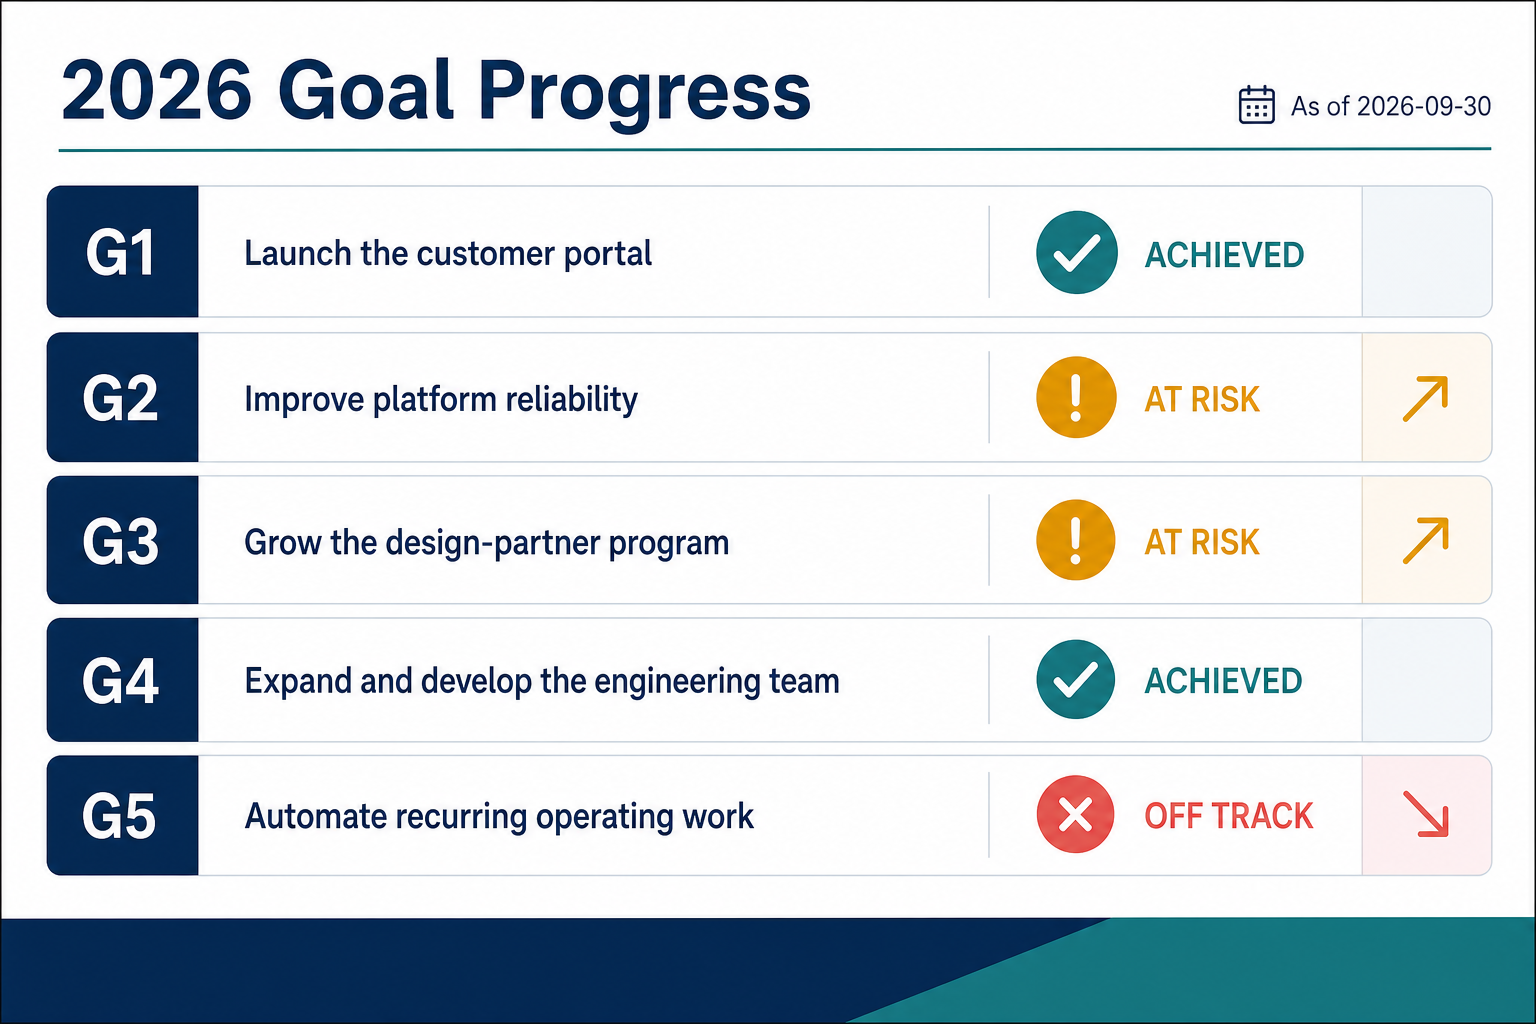

In [28]:
def infographic_prompt(report: PortfolioReport):
    rows = [f"{item.goal_id} — {item.title}: {item.status.value.replace('_', ' ')}" for item in report.assessments]
    return '''Create a clean landscape executive infographic titled '2026 Goal Progress'.
Use a professional navy, teal, amber, and coral palette. Show the as-of date,
five clearly separated goal lanes, a simple status icon for each lane, and small
arrows where a goal changed. Keep text minimal and do not invent numbers or facts.
Use only this summary:\n''' + f"As of {report.as_of_date.isoformat()}\n" + "\n".join(rows)


def generate_infographic(report, client, filename="goal_progress_infographic.png"):
    result = client.images.generate(
        model=IMAGE_MODEL,
        prompt=infographic_prompt(report),
        size="1536x1024",
        quality="medium",
    )
    Path(filename).write_bytes(base64.b64decode(result.data[0].b64_json))
    print(f"Saved {filename}")
    return filename


if GENERATE_INFOGRAPH and final_state:
    image_path = generate_infographic(final_state.final_report, app.client)
    display(Image(filename=image_path))

## What to try next

- Change `CURRENT_DATE` to see how the same raw text produces an earlier or later assessment.
- Set `TESTMODE = True` and `RUN_FULL_GRAPH = False` to run one agent at a time.
- Add another plain-text message between separator lines and compare the evidence.
- Replace a reader function with one that returns text from another source.